### Streaming 
#### Methods: .stream() and astream()
- These methods are sync and async methods for streaming back results.
Additional parameters in streaming modes for graph state

- values: This streams the full state of the graph after each node is called
- updates: This streams updates to the state of the graph after each node is called

In [1]:
from typing_extensions import TypedDict
from langgraph.graph import StateGraph, START, END

## Reducers
from typing import Annotated
from langgraph.graph.message import add_messages


In [2]:
class State(TypedDict):
    messages: Annotated[list, add_messages]
    

In [3]:
import os
from dotenv import load_dotenv
load_dotenv()

os.environ["OPENAI_API_KEY"] = os.getenv("OPENAI_API_KEY")
os.environ["GROQ_API_KEY"] = os.getenv("GROQ_API_KEY")


In [4]:
from langchain_groq import ChatGroq
llm = ChatGroq(model="qwen/qwen3-32b")
llm.invoke("Hello")

AIMessage(content='<think>\nOkay, the user just said "Hello". I need to respond appropriately. Let me start by acknowledging their greeting. A simple "Hello!" should work. Then, I should offer assistance. Maybe ask how I can help them today. Keep it friendly and open-ended. Let me make sure the tone is welcoming. Yeah, that should do it.\n</think>\n\nHello! How can I assist you today? 😊', additional_kwargs={}, response_metadata={'token_usage': {'completion_tokens': 86, 'prompt_tokens': 9, 'total_tokens': 95, 'completion_time': 0.155185575, 'completion_tokens_details': None, 'prompt_time': 0.000318915, 'prompt_tokens_details': None, 'queue_time': 0.052891954, 'total_time': 0.15550449}, 'model_name': 'qwen/qwen3-32b', 'system_fingerprint': 'fp_5cf921caa2', 'service_tier': 'on_demand', 'finish_reason': 'stop', 'logprobs': None, 'model_provider': 'groq'}, id='lc_run--019e98c3-427d-7111-8056-fde63206a4e5-0', tool_calls=[], invalid_tool_calls=[], usage_metadata={'input_tokens': 9, 'output_to

### We will start with Creating Nodes

In [11]:
from langgraph.checkpoint.memory import MemorySaver
memory = MemorySaver()
def superbot(state:State):
    return {"messages": [llm.invoke(state["messages"])]}

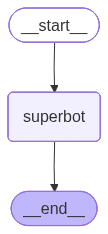

In [12]:
graph = StateGraph(State)

## node
graph.add_node("superbot", superbot)

## edges
graph.add_edge(START, "superbot")
graph.add_edge("superbot", END)

graph_builder = graph.compile(checkpointer=memory)

## Display
from IPython.display import Image, display
display(Image(graph_builder.get_graph().draw_mermaid_png()))

In [13]:
## Invocation

config = {"configurable": {"thread_id": "2"}}
graph_builder.invoke({"messages": "Hi, My name is Deepak and I like paneer"},config=config)

{'messages': [HumanMessage(content='Hi, My name is Deepak and I like paneer', additional_kwargs={}, response_metadata={}, id='2d173b48-6de8-4157-a699-0a260841ecfe'),
  AIMessage(content="<think>\nOkay, the user introduced himself as Deepak and mentioned he likes paneer. I should acknowledge his introduction and express interest in his preference for paneer. I can ask a follow-up question or share a related thought to keep the conversation going. I need to keep the response friendly and engaging, maybe suggest trying different paneer dishes or recipes if he's interested. I should keep it natural and not too formal.\n</think>\n\nHi Deepak! Nice to meet you. Paneer is such a delicious choice – I'd love to hear your favorite way to enjoy it! 🧀 Whether it's in a curry, grilled, or part of a sandwich, paneer is really versatile. Do you have a particular recipe or dish you'd recommend?", additional_kwargs={}, response_metadata={'token_usage': {'completion_tokens': 153, 'prompt_tokens': 20, 't

### Streaming The Responses with Stream Method

In [14]:
# create a thread
config = {"configurable": {"thread_id": "4"}}

for chunk in graph_builder.stream({"messages": "Hi, My name is Deepak and I like Paneer"}, config=config, stream_mode="updates"):
    print(chunk)


{'superbot': {'messages': [AIMessage(content="<think>\nOkay, the user introduced himself as Deepak and mentioned he likes paneer. I should respond in a friendly and open-ended way to encourage conversation. First, acknowledge his name and confirm that paneer is his favorite. Then ask a question to learn more about his preferences. Maybe ask about specific ways he enjoys paneer, like dishes or regional variations. Keep it simple and conversational. Make sure to use casual language and avoid any markdown formatting. Check for typos and ensure the response flows naturally.\n</think>\n\nHi Deepak! That's awesome—paneer is such a versatile and tasty choice! 🧀 Do you have a favorite way to enjoy it, like in a dish (maybe butter paneer, palak paneer?), or a specific regional style you love? I’d love to hear more! 😊", additional_kwargs={}, response_metadata={'token_usage': {'completion_tokens': 169, 'prompt_tokens': 20, 'total_tokens': 189, 'completion_time': 0.436515086, 'completion_tokens_de

In [15]:
# create a thread
config = {"configurable": {"thread_id": "4"}}

for chunk in graph_builder.stream({"messages": "Hi, My name is Deepak and I like Paneer"}, config=config, stream_mode="values"):
    print(chunk)

{'messages': [HumanMessage(content='Hi, My name is Deepak and I like Paneer', additional_kwargs={}, response_metadata={}, id='4d6297f2-fb84-4299-a12b-bf2c3385d160'), AIMessage(content="<think>\nOkay, the user introduced himself as Deepak and mentioned he likes paneer. I should respond in a friendly and open-ended way to encourage conversation. First, acknowledge his name and confirm that paneer is his favorite. Then ask a question to learn more about his preferences. Maybe ask about specific ways he enjoys paneer, like dishes or regional variations. Keep it simple and conversational. Make sure to use casual language and avoid any markdown formatting. Check for typos and ensure the response flows naturally.\n</think>\n\nHi Deepak! That's awesome—paneer is such a versatile and tasty choice! 🧀 Do you have a favorite way to enjoy it, like in a dish (maybe butter paneer, palak paneer?), or a specific regional style you love? I’d love to hear more! 😊", additional_kwargs={}, response_metadata

In [17]:
for chunk in graph_builder.stream({"messages": "I like cricket"}, config=config, stream_mode="values"):
    print(chunk)

{'messages': [HumanMessage(content='Hi, My name is Deepak and I like Paneer', additional_kwargs={}, response_metadata={}, id='4d6297f2-fb84-4299-a12b-bf2c3385d160'), AIMessage(content="<think>\nOkay, the user introduced himself as Deepak and mentioned he likes paneer. I should respond in a friendly and open-ended way to encourage conversation. First, acknowledge his name and confirm that paneer is his favorite. Then ask a question to learn more about his preferences. Maybe ask about specific ways he enjoys paneer, like dishes or regional variations. Keep it simple and conversational. Make sure to use casual language and avoid any markdown formatting. Check for typos and ensure the response flows naturally.\n</think>\n\nHi Deepak! That's awesome—paneer is such a versatile and tasty choice! 🧀 Do you have a favorite way to enjoy it, like in a dish (maybe butter paneer, palak paneer?), or a specific regional style you love? I’d love to hear more! 😊", additional_kwargs={}, response_metadata

In [18]:
for chunk in graph_builder.stream({"messages": "I like new food"}, config=config, stream_mode="values"):
    print(chunk)

{'messages': [HumanMessage(content='Hi, My name is Deepak and I like Paneer', additional_kwargs={}, response_metadata={}, id='4d6297f2-fb84-4299-a12b-bf2c3385d160'), AIMessage(content="<think>\nOkay, the user introduced himself as Deepak and mentioned he likes paneer. I should respond in a friendly and open-ended way to encourage conversation. First, acknowledge his name and confirm that paneer is his favorite. Then ask a question to learn more about his preferences. Maybe ask about specific ways he enjoys paneer, like dishes or regional variations. Keep it simple and conversational. Make sure to use casual language and avoid any markdown formatting. Check for typos and ensure the response flows naturally.\n</think>\n\nHi Deepak! That's awesome—paneer is such a versatile and tasty choice! 🧀 Do you have a favorite way to enjoy it, like in a dish (maybe butter paneer, palak paneer?), or a specific regional style you love? I’d love to hear more! 😊", additional_kwargs={}, response_metadata

In [19]:
for chunk in graph_builder.stream({"messages": "I like cricket"}, config=config, stream_mode="updates"):
    print(chunk)

{'superbot': {'messages': [AIMessage(content='<think>\nOkay, the user mentioned they like cricket again. Let me look at the history to see where we left off. Oh right, they said they like cricket, and I asked about their favorite team or player. Now they\'re repeating "I like cricket." Maybe they want to expand on that.\n\nIn the previous messages, they also mentioned liking paneer and new food. So perhaps they\'re connecting their love for cricket with food? Maybe they enjoy food while watching cricket or have favorite snacks during matches. I should ask if they have any traditional or favorite foods they eat while watching games. Also, maybe they like the social aspect of cricket, like attending matches or gatherings. Let me check if they play or just watch. Maybe they have a team they follow passionately. I need to make the questions engaging and connect back to their other interests like food. Let\'s see, how to bridge cricket and food in a question. Maybe something like, "Do you h

### Streaming The Responses with astream Method

Streaming Tokens we often want to stream more than graph state

In particular, with chat model calls it is commo to stream the tokens as theu are generated.

We can do this using the .astream_events method, which streams back events as they happen inside nodes

Each event is a dict with few keys:
 - events: This is the type of event that is being emitted
 - name: this is the name of event
 - data: this is the data associated with the event
 - metadata: Containslanggraph_node, the node emitting the event

In [20]:
config = {"configurable": {"thread_id": "5"}}
async for event in graph_builder.astream_events({"messages":["Hi My name is Deepak and I like to play cricket"]}, config=config, version="v2"):
    print(event)

{'event': 'on_chain_start', 'data': {'input': {'messages': ['Hi My name is Deepak and I like to play cricket']}}, 'name': 'LangGraph', 'tags': [], 'run_id': '019e9c7d-b3e0-7dd2-9263-d1a7525d699e', 'metadata': {'thread_id': '5', 'ls_integration': 'langgraph'}, 'parent_ids': []}
{'event': 'on_chain_start', 'data': {'input': {'messages': [HumanMessage(content='Hi My name is Deepak and I like to play cricket', additional_kwargs={}, response_metadata={}, id='69e0be64-6b19-4876-91ba-8a93c5de2ece')]}}, 'name': 'superbot', 'tags': ['graph:step:1'], 'run_id': '019e9c7d-b3e4-7742-9990-132e831f5136', 'metadata': {'thread_id': '5', 'ls_integration': 'langgraph', 'langgraph_step': 1, 'langgraph_node': 'superbot', 'langgraph_triggers': ('branch:to:superbot',), 'langgraph_path': ('__pregel_pull', 'superbot'), 'langgraph_checkpoint_ns': 'superbot:90188990-3d20-b098-66bb-8886af538231'}, 'parent_ids': ['019e9c7d-b3e0-7dd2-9263-d1a7525d699e']}
{'event': 'on_chat_model_start', 'data': {'input': {'messages